# Validação dos resultados do modelo

Validação dos rasters produzidos nas etapas anteriores:
* susceptibilidade
* probabilidade
* perigosidade.

Avaliação do desempenho do modelo.

In [1]:
refs = {
    '1995-2024': '/code/data/processed/centro/area_ardida/raster_binary/rst_ba_1995_2024_bin.tif',
    '2025'     : '/code/data/processed/centro/area_ardida/raster_binary/rst_ba_2025_bin.tif'
}

perigos = {
    'dem'   : '/code/data/results/centro/lr/final/lri_dem.tif',
    'slope' : '/code/data/results/centro/lr/final/lri_slope.tif',
    #'aspect': '/code/data/results/centro/lr/final/lri_aspect.tif',
    'lulc'  : '/code/data/results/centro/lr/final/lri_lulc.tif',
    'lri'   : '/code/data/results/centro/lr/final/res_lri.tif',
    'prob'  : '/code/data/results/centro/lr/final/wprobability.tif',
    'peri'  : '/code/data/results/centro/lr/final/res_perigosity.tif'
}

val = 1

otbl = '/code/data/results/centro/lr/validation/valida_lri.xlsx'

In [2]:
import os
import pandas as pd
from glass.pys.oss import fprop, lst_ff
from glass.ete.perig.eval import pseudo_roc
from glass.wt import obj_to_tbl

#ALTERAÇÃO À VALIDAÇÃO

import sys

sys.path.append("/code/scripts")
from validation import pseudo_roc_blocks

In [3]:
ftbl = []

reflst = list(refs.keys())
for p in perigos:
    rname = fprop(perigos[p], "fn")
    row = [p, rname]
    for ref in reflst:
        vtbl, rauc, pseudo_auc = pseudo_roc_blocks(
            refs[ref], perigos[p], val,
            os.path.join(os.path.dirname(otbl), f'{p}_{rname}_{ref}.xlsx')
        )

        row.append(rauc)

    ftbl.append(row)

fdf = pd.DataFrame(ftbl, columns=['alias', 'perigosity'] + reflst)

obj_to_tbl(fdf, otbl)

/glass/glass/wt/__init__.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  row[c] = str(row[c])
/glass/glass/wt/__init__.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  row[c] = str(row[c])
/glass/glass/wt/__init__.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  row[c] = str(row[c])
/glass/glass/wt/__init__.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' 

'/code/data/results/centro/lr/validation/valida_lri.xlsx'

In [4]:
rauc

0.7050319973959142

In [5]:
vtbl

'/code/data/results/centro/lr/validation/peri_res_perigosity_2025.xlsx'

In [6]:
pseudo_auc

0.7050319973959144

In [7]:
vtbl, rauc, pseudo_auc = pseudo_roc_blocks(
    '/code/data/processed/centro/area_ardida/raster_binary/rst_ba_2025_bin.tif',
    '/code/data/results/centro/lr/final/res_perigosity.tif',
    val
)

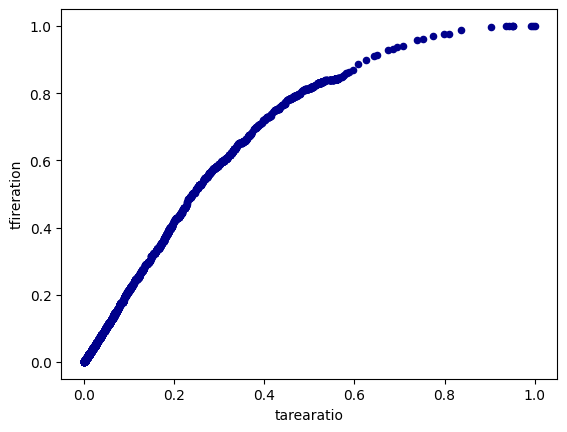

In [8]:
ax1 = vtbl.plot.scatter(x='tarearatio', y='tfireration',c='DarkBlue')

In [9]:
# Verificsr
fdf

,alias,perigosity,1995-2024,2025
0,dem,lri_dem,0.573948,0.607351
1,slope,lri_slope,0.580905,0.626285
2,lulc,lri_lulc,0.608937,0.662651
3,lri,res_lri,0.628362,0.702892
4,prob,wprobability,0.798682,0.717260
5,peri,res_perigosity,0.733588,0.705032
